# NIFH DIAZATROPS DATA SET
This notebook aims to explore and analyze the data from the 2 datasets with focus on the nifh gene data sheet in .xls file.

In [112]:
import sys
print(sys.executable)

/usr/bin/python


In [113]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib

There are some files that need to be present for this notebook to work:
- ***./csv/DiazotrophsDatabase-20240109_nifh.csv***
- ***./csv/MAREDAT_diazotroph_nifh.csv***
- ***./csv/Tang_GeophysicalResLett_2019_Data_nifh.csv***

Each takes the data from the nifh_gene sheet of the corresponding exel file that I export as a csv file in order to be processed using pandas.

There are some simple functions we would like to use for both datasets that I also used in another notebook(obs_diazotr.ipynb). And since they are useful and can and should be used here i copied over the code. Some of them though are specific to this notebook and are new.

In [114]:
#this function removes all not specified columns from the dataframe
def removeRed(keepers, df):
    cols = set(df.columns) - set(keepers)
    df.drop(columns=list(cols), inplace=True)

#this function converts object columns to numeric
def objToNum(df):
    object_columns = df.select_dtypes(include='object').columns.tolist()
    for col in object_columns:
        df[col]=pd.to_numeric(df[col], errors="coerce")

#after all filtering we might have some rows completely empty which we should remove
def removeEmptyRows(cols, df):
    df.dropna(subset=cols, how='all', inplace=True)

#since only depth <= 25 meters is studied this needs to be filtered for
def filterDepth(df):
    df_mask = (df["DEPTH (m)"] <=25)
    df_depth = df[df_mask]
    return df_depth

In [115]:
#this function rounds the coordinate columns and returns the resulting dataframe
def roundCoord(cols, df):
    #we separate the data and coordinates in order to round the coordinate grid
    lat_rnd = np.round(df['LATITUDE'])
    lon_rnd = np.round(df['LONGITUDE'])
    data = df[cols]

    #we join the data back together
    df_rnd = pd.concat([lat_rnd, lon_rnd, data], axis=1)
    return df_rnd

Since we want to plot the csv data as a scatter plot on the globe quite frequently I thought it would be useful to separate that functionality into a new function. 

Due to seeing the initial results of plotting the data and its histograms logorithmic scale is applied like in the papers. Also, there is an option to set the range to be exactly like in the paper as well, but for it to work better the data has to be multiplied by $10^6$ in order to put most data points within the specified range.

In [116]:
def plotColsOnMap(cols,df, log_range = False):
    #the index is reset from using lat and lon just in case
    df_reset = df.reset_index()

    #the number of rows varies depending on the number of columns to plot
    rows = (len(cols)//2) + (len(cols)%2==1)

    #a set of subplots is created
    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, rows*4), subplot_kw={"projection": ccrs.PlateCarree()})

    #we plot each column
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]#subplot

        #we want to see the coastlines on the globe and only take not null values
        ax.add_feature(cfeature.COASTLINE)
        valid_data = df_reset[df_reset[col].notna()]

        #this sets the logorithmic scale to be exactly like in the paper instead of default
        norm = matplotlib.colors.LogNorm(vmin=1e3, vmax=1e11)
        if(not log_range):
            norm = matplotlib.colors.LogNorm()

        #scatter plot is created
        sc = ax.scatter(
            valid_data["LONGITUDE"],
            valid_data["LATITUDE"],
            c=valid_data[col]*(10**6),
            cmap="viridis",
            s=40,
            transform=ccrs.PlateCarree(),
            norm=norm
        )

        #we want to see the entire globe and not just the values 
        ax.set_xlim(-180,180)
        ax.set_ylim(-90,90)

        plt.colorbar(sc, ax=ax, label="nifH Gene (copies m-3)")
        ax.set_title(col.replace("x106 ",""))

    plt.tight_layout()
    plt.show()

There is a list of columns we actually want to keep in the final set in order to predict them. Other columns are not needed for this project and can be removed.

In [117]:
keepers = ['LATITUDE', 'LONGITUDE', 'DEPTH (m)','Trichodesmium nifH Gene (x106 copies m-3)', 'Total UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)',"UCYN-A nifH Gene (x106 copies m-3)"]

# First dataset
This dataset is from the paper [Global oceanic diazotroph database version 2 and
elevated estimate of global oceanic N2 fixation](https://essd.copernicus.org/articles/15/3673/2023/essd-15-3673-2023-assets.html). (Luo)

In [118]:
#we want to remember which columns here to show
dzdb_cols = ['Trichodesmium nifH Gene (x106 copies m-3)', 'Total UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

#the dataset is opened
dzdb_2024_nifh = pd.read_csv("./csv/DiazotrophsDatabase-20240109_nifh.csv")
print(dzdb_2024_nifh.info())
dzdb_2024_nifh.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5580 entries, 0 to 5579
Data columns (total 25 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   SOURCE: Related article or authors                         143 non-null    object 
 1   METHODS:                  Sampling/Analysis                5580 non-null   object 
 2   DATE (yyyy-mm-dd)                                          5580 non-null   object 
 3   LATITUDE                                                   5580 non-null   float64
 4   LONGITUDE                                                  5580 non-null   float64
 5   DEPTH (m)                                                  5580 non-null   float64
 6   Trichodesmium nifH Gene (x106 copies m-3)                  4192 non-null   object 
 7   UCYN-A1 nifH Gene (x106 copies m-3)                        4387 non-null   object 
 8   UCYN-A2/

,SOURCE: Related article or authors,METHODS: Sampling/Analysis,DATE (yyyy-mm-dd),LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),UCYN-A1 nifH Gene (x106 copies m-3),UCYN-A2/A3/A4 nifH Gene (x106 copies m-3),Total UCYN-A nifH Gene (x106 copies m-3),...,Richelia (het-2 or ReuHH01) nifH Gene (x106 copies m-3),Richelia ( RrhiSC01) nifH Gene (x106 copies m-3),Temperature (˚C),Salinity (PSU),Nitrate (µM),Phosphate (µM),Fe (nM),SiO2 (µM),Chlorophyll (mg m-3),Notes
0,"Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,10/31/2004,-9.00,-136.86,5.0,0.000,0.03,NaN,0.03,...,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,qPCR,11/3/2004,-11.51,-134.35,5.0,0.000,0.00,NaN,0.00,...,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,qPCR,11/4/2004,-13.31,-132.39,70.0,0.000,0.00,NaN,0.00,...,NaN,0.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,qPCR,11/5/2004,-15.20,-130.20,5.0,0.000,0.00,NaN,0.00,...,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,qPCR,11/6/2004,-16.87,-128.38,5.0,0.000,0.00,NaN,0.00,...,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [119]:
#I removed all redundant columns and made everything into a number
removeRed(keepers, dzdb_2024_nifh)
objToNum(dzdb_2024_nifh)

dzdb_2024_nifh_df = filterDepth(dzdb_2024_nifh)
removeEmptyRows(dzdb_cols,dzdb_2024_nifh_df)

/tmp/ipykernel_18633/3644107321.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=cols, how='all', inplace=True)


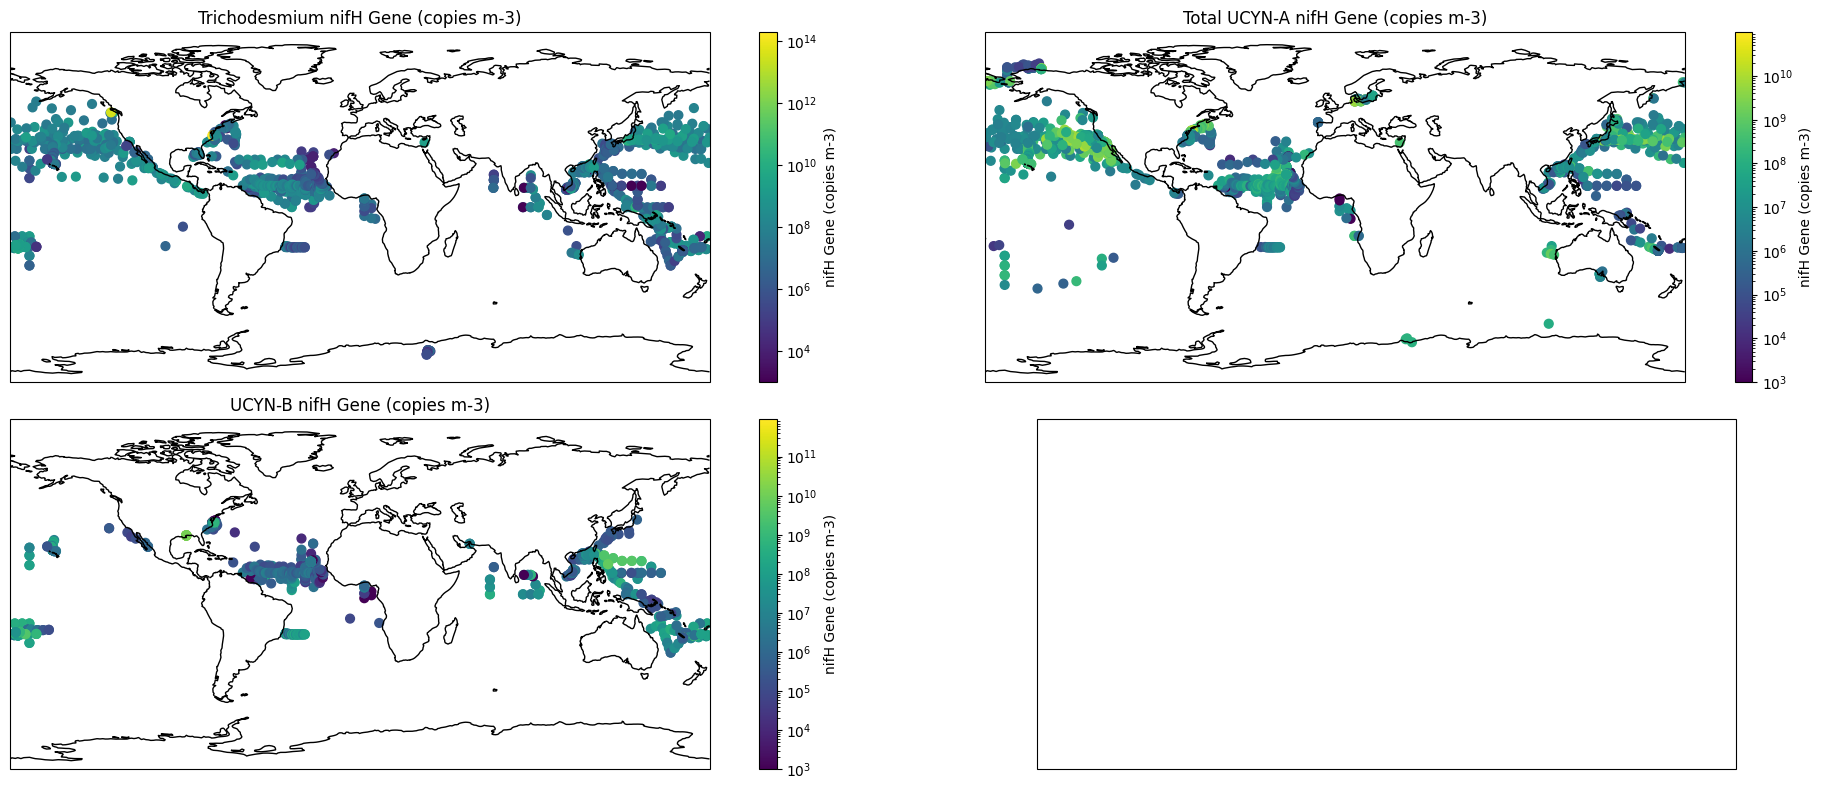

In [120]:

#we also want to plot the contents of the dataset on the map, which we can do now as all data is numeric

plotColsOnMap(dzdb_cols, dzdb_2024_nifh_df)

As a result we got a significantly smaller number of entries, which is especially seen with the data columns. But now we only have the data we actually want and need.

In [121]:
dzdb_2024_nifh_df.describe()

,LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),Total UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
count,2476.000000,2476.000000,2476.000000,1.789000e+03,1919.000000,1403.000000
mean,18.090424,-10.171099,7.165145,1.272132e+05,426.088841,1372.586068
std,26.044465,127.372819,7.509356,4.572887e+06,3070.100360,26245.050587
min,-75.950000,-179.630000,0.000000,0.000000e+00,0.000000,0.000000
25%,8.967500,-136.625000,2.000000,1.190000e+00,0.270000,0.000000
50%,22.750000,-35.000000,5.000000,1.810000e+01,6.490000,1.146000
75%,33.835000,129.117500,10.000000,1.415000e+02,104.980000,22.803000
max,119.830000,187.330000,25.000000,1.900000e+08,99700.000000,898000.000000


# Second dataset
This is the dataset from the  [Database of diazotrophs in global ocean: abundance, biomass and nitrogen fixation rates](https://doi.pangaea.de/10.1594/PANGAEA.774851)

In [122]:
#here we open the dataset of the other database for cell count
maredat_nifh = pd.read_csv("./csv/MAREDAT_diazotroph_nifh.csv")
print(maredat_nifh.shape)
print(maredat_nifh.columns)
maredat_nifh.head()

(921, 35)
Index(['SOURCE: Data', 'SOURCE: Related article',
       'METHODS:                  Sampling/Analysis', 'DATE (yyyy-mm-dd)',
       'LATITUDE', 'LONGITUDE', 'DEPTH (m)',
       'Trichodesmium nifH Gene (x106 copies m-3)',
       'Trichodesmium Biomass Conversion factor (mg C/106 nifH copies)',
       'Trichodesmium Biomass (mg C m-3)',
       'UCYN-A nifH Gene (x106 copies m-3)',
       'UCYN-A Biomass Conversion factor (mg C/106 nifH copies)',
       'UCYN-B nifH Gene (x106 copies m-3)',
       'UCYN-B Biomass Conversion factor (mg C/106 nifH copies)',
       'UCYN-C nifH Gene (x106 copies m-3)',
       'UCYN-C Biomass Conversion factor (mg C/106 nifH copies)',
       'UCYN Biomass (mg C m-3)', 'Richelia Associated Species',
       'Richelia nifH Gene (x106 copies m-3)',
       'Richelia Biomass Conversion factor (mg C/106 nifH copies)',
       'Calothrix Associated Species',
       'Calothrix nifH Gene  (x106 copies m-3)',
       'Calothrix Biomass Conversion factor (mg C/1

,SOURCE: Data,SOURCE: Related article,METHODS: Sampling/Analysis,DATE (yyyy-mm-dd),LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),Trichodesmium Biomass Conversion factor (mg C/106 nifH copies),Trichodesmium Biomass (mg C m-3),...,Temperature (˚C),Salinity (PSU),Nitrate (µM),Phosphate (µM),Fe (nM),Chlorophyll (mg m-3),Notes,Gamma A nifH Gene (x106 copies/m3),Gamma P nifH Gene (x106 copies/m3),CIII nifH Gene (x106 copies/m3)
0,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-10-31,-9.00,-136.86,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-03,-11.51,-134.35,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-04,-13.31,-132.39,70,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-05,-15.20,-130.20,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-06,-16.87,-128.38,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [123]:
maredat_nifh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 921 entries, 0 to 920
Data columns (total 35 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   SOURCE: Data                                                    825 non-null    object 
 1   SOURCE: Related article                                         878 non-null    object 
 2   METHODS:                  Sampling/Analysis                     921 non-null    object 
 3   DATE (yyyy-mm-dd)                                               921 non-null    object 
 4   LATITUDE                                                        921 non-null    float64
 5   LONGITUDE                                                       921 non-null    float64
 6   DEPTH (m)                                                       921 non-null    int64  
 7   Trichodesmium nifH Gene (x106 copies m-3)            

In [124]:
#I removed all redundant columns and made everything into a number
removeRed(keepers, maredat_nifh)
objToNum(maredat_nifh)

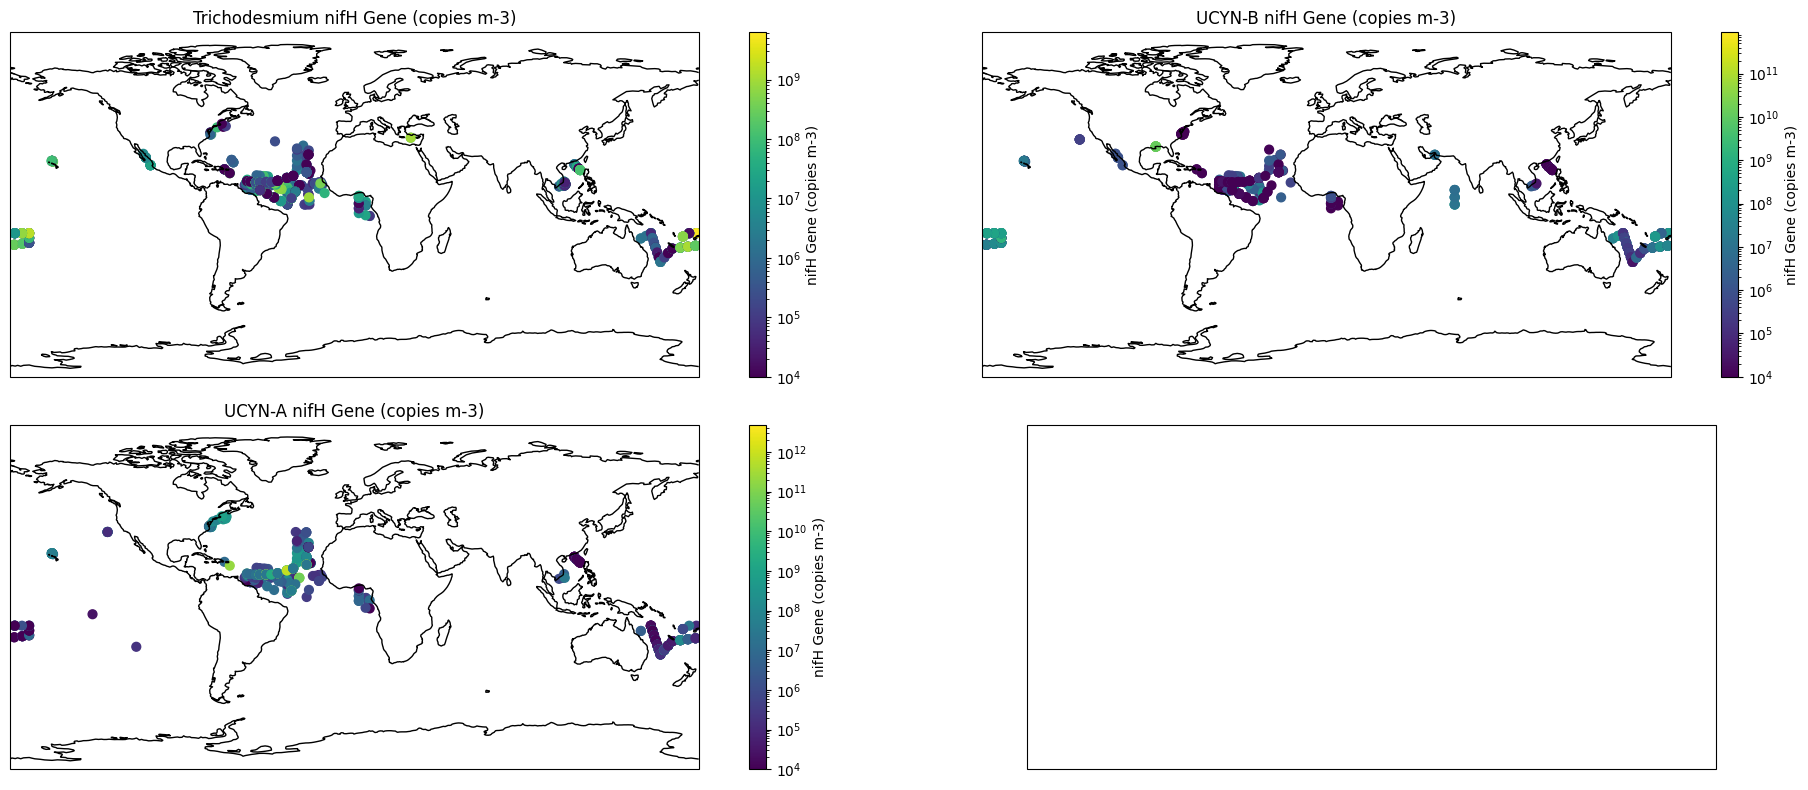

In [125]:
#the points in the dataset are plotted on the map
bact_cols =['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)',"UCYN-A nifH Gene (x106 copies m-3)"]
plotColsOnMap(bact_cols, maredat_nifh)

In [126]:
#since we only want to work with data from the first 25m this needs to be filtered for
maredat_nifh_depthmask = (maredat_nifh["DEPTH (m)"] <=25)
maredat_nifh_df = maredat_nifh[maredat_nifh_depthmask]

#display result
print(maredat_nifh.columns)
maredat_nifh_df.info()

Index(['LATITUDE', 'LONGITUDE', 'DEPTH (m)',
       'Trichodesmium nifH Gene (x106 copies m-3)',
       'UCYN-A nifH Gene (x106 copies m-3)',
       'UCYN-B nifH Gene (x106 copies m-3)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 450 entries, 0 to 915
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   450 non-null    float64
 1   LONGITUDE                                  450 non-null    float64
 2   DEPTH (m)                                  450 non-null    int64  
 3   Trichodesmium nifH Gene (x106 copies m-3)  338 non-null    float64
 4   UCYN-A nifH Gene (x106 copies m-3)         339 non-null    float64
 5   UCYN-B nifH Gene (x106 copies m-3)         357 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 24.6 KB


In [127]:
maredat_nifh_df.describe()

,LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
count,450.000000,450.000000,450.000000,338.000000,3.390000e+02,357.000000
mean,18.242689,-17.170578,8.053333,155.754477,3.555933e+04,4443.817921
std,22.913159,87.228526,7.250639,484.371625,3.637835e+05,50860.230964
min,-31.820000,-177.770000,0.000000,0.000000,0.000000e+00,0.000000
25%,7.790000,-67.665000,4.000000,0.065150,0.000000e+00,0.000000
50%,15.650000,-29.385000,5.000000,3.065000,5.350000e-01,0.010000
75%,30.300000,17.500000,12.250000,66.080725,3.359110e+01,9.700000
max,57.380000,178.750000,25.000000,6266.844800,4.810000e+06,898000.000000


In [128]:
mar_cols = ['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']
removeEmptyRows(mar_cols,maredat_nifh_df)

maredat_nifh_df.shape

/tmp/ipykernel_18633/3644107321.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=cols, how='all', inplace=True)


(381, 6)

# Third dataset

This is an additional dataset that is meant to contain more diverse data than the first 2.

In [129]:
tang_nifh = pd.read_csv("./csv/Tang_GeophysicalResLett_2019_Data_nifh.csv")
print(tang_nifh.info())
tang_nifh.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2006 entries, 0 to 2005
Data columns (total 43 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   SOURCE: Data                                                    37 non-null     object 
 1   METHODS:                  Sampling/Analysis                     2006 non-null   object 
 2   DATE (mm/dd/yyyy)                                               2006 non-null   object 
 3   LATITUDE                                                        2006 non-null   float64
 4   LONGITUDE                                                       2006 non-null   float64
 5   DEPTH (m)                                                       2006 non-null   object 
 6   Trichodesmium nifH Gene (x106 copies m-3)                       1429 non-null   object 
 7   Trichodesmium Biomass Conversion factor (mg C/106 n

,SOURCE: Data,METHODS: Sampling/Analysis,DATE (mm/dd/yyyy),LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),Trichodesmium Biomass Conversion factor (mg C/106 nifH copies),Trichodesmium Biomass (mg C m-3),UCYN-A1 nifH Gene (x106 copies m-3),...,Total nifH Gene (x106 copies/m3),Total Diazotrophic Biomass (mg C m-3),Temperature (˚C),Salinity (PSU),Nitrate (µM),Phosphate (µM),N:P ratio,Fe (nM),Chlorophyll (mg m-3),Notes
0,"Hannah Halm et al., 2012 ISME",qPCR,Dec 2006/Jan 2007,-27.91,-123.16,0.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,qPCR,Dec 2006/Jan 2007,-27.91,-123.16,150.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,data shown in Table 2,qPCR,Dec 2006/Jan 2007,-27.73,-117.61,0.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,qPCR,Dec 2006/Jan 2007,-27.73,-117.61,220.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,qPCR,Dec 2006/Jan 2007,-38.06,-133.10,0.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [130]:
tang_cols = ['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

removeRed(keepers, tang_nifh)
objToNum(tang_nifh)
tang_nifh_d = filterDepth(tang_nifh)
removeEmptyRows(tang_cols,tang_nifh_d)

tang_nifh_d.info()

<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 2000
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   784 non-null    float64
 1   LONGITUDE                                  784 non-null    float64
 2   DEPTH (m)                                  784 non-null    float64
 3   Trichodesmium nifH Gene (x106 copies m-3)  573 non-null    float64
 4   UCYN-A nifH Gene (x106 copies m-3)         652 non-null    float64
 5   UCYN-B nifH Gene (x106 copies m-3)         553 non-null    float64
dtypes: float64(6)
memory usage: 42.9 KB


/tmp/ipykernel_18633/3644107321.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=cols, how='all', inplace=True)


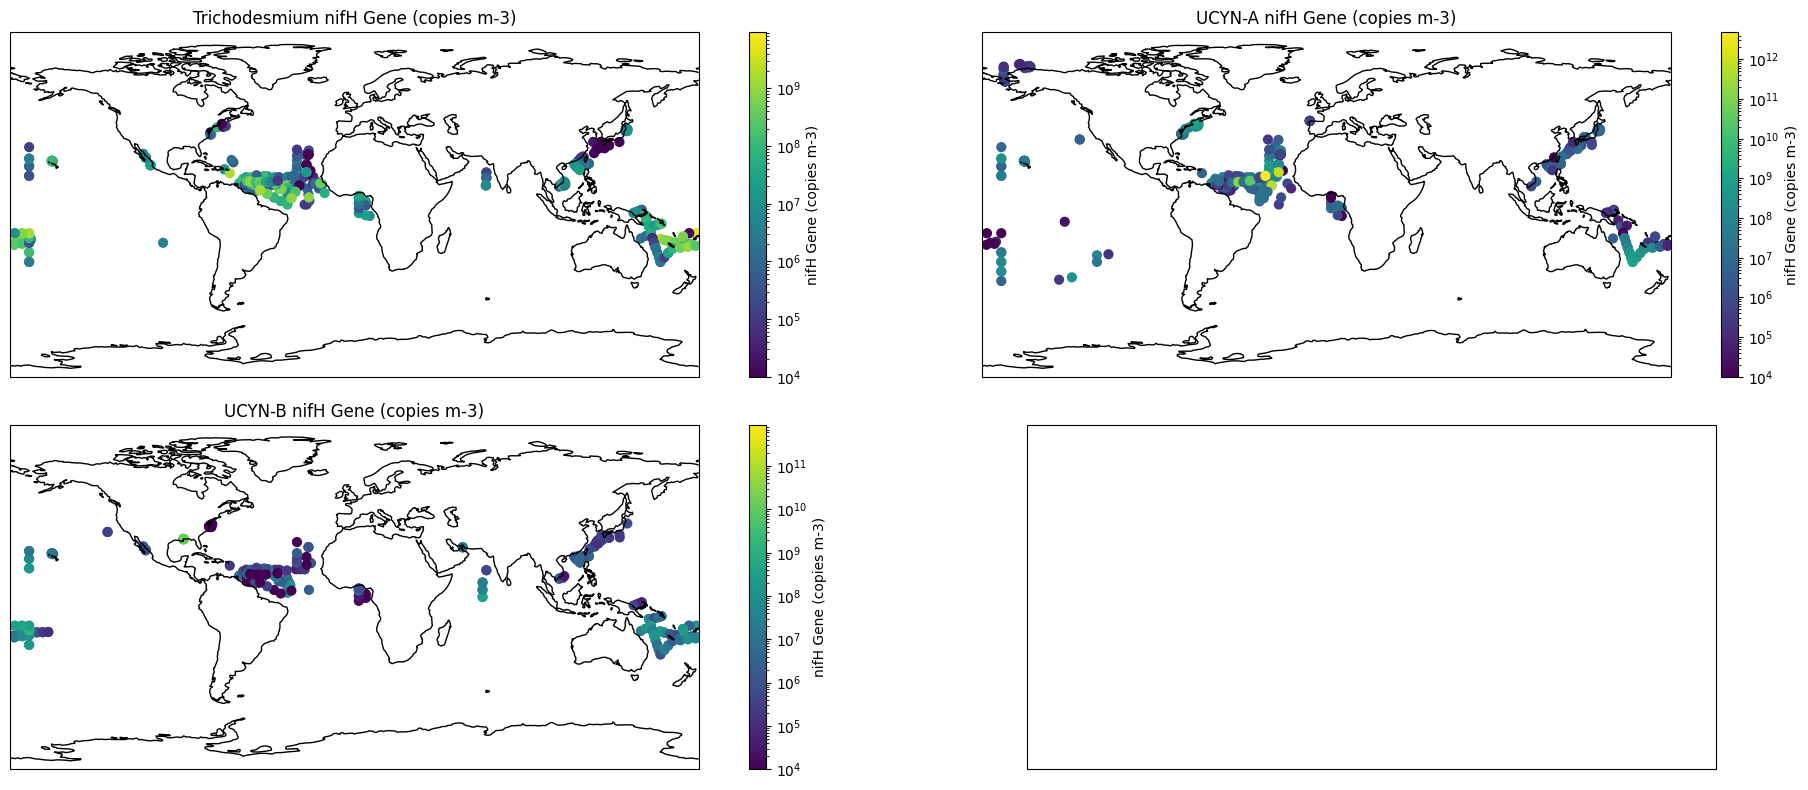

In [131]:

plotColsOnMap(tang_cols,tang_nifh_d)

In [132]:
tang_nifh_d.describe()

,LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
count,784.000000,784.000000,784.000000,573.000000,6.520000e+02,553.000000
mean,10.242015,25.350842,7.485714,186.408086,9.987612e+03,2904.475367
std,24.284745,120.408614,7.252859,714.216965,1.926663e+05,40898.087432
min,-40.000000,-178.510000,0.000000,0.000000,0.000000e+00,0.000000
25%,-15.050000,-64.410000,2.500000,0.070000,0.000000e+00,0.000000
50%,11.750000,5.925000,5.000000,4.460000,8.850000e-01,0.510000
75%,26.000000,142.000000,12.000000,75.125000,1.333750e+01,10.240000
max,73.480000,178.750000,25.000000,9413.540000,4.810000e+06,898000.000000


# Combining both of them together into 1
Since both datasets have been cleaned and prepared, we can finally try joining them together into a single table that we can later combine with environmental data and train the model.

The first step is to rename the column names that do not match and concatenate the 2 dataframes together into a single one.

In [133]:
rename_map = {"Total UCYN-A nifH Gene (x106 copies m-3)":"UCYN-A nifH Gene (x106 copies m-3)"}

renamed_set = dzdb_2024_nifh_df.rename(columns=rename_map)
combined_df = pd.concat([renamed_set, maredat_nifh_df])

combined_df.head()

,LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
0,-9.00,-136.86,5.0,0.0,0.03,0.0
1,-11.51,-134.35,5.0,0.0,0.00,0.0
3,-15.20,-130.20,5.0,0.0,0.00,0.0
4,-16.87,-128.38,5.0,0.0,0.00,0.0
5,-20.13,-123.41,5.0,0.0,NaN,0.0


In [134]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2857 entries, 0 to 915
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   2857 non-null   float64
 1   LONGITUDE                                  2857 non-null   float64
 2   DEPTH (m)                                  2857 non-null   float64
 3   Trichodesmium nifH Gene (x106 copies m-3)  2127 non-null   float64
 4   UCYN-A nifH Gene (x106 copies m-3)         2258 non-null   float64
 5   UCYN-B nifH Gene (x106 copies m-3)         1760 non-null   float64
dtypes: float64(6)
memory usage: 156.2 KB


After joining them together we want to plot the distributions in the resulting data.*bact_cols* list all columns that contain bacterial data, that we want to show.

In [135]:
bact_cols=['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

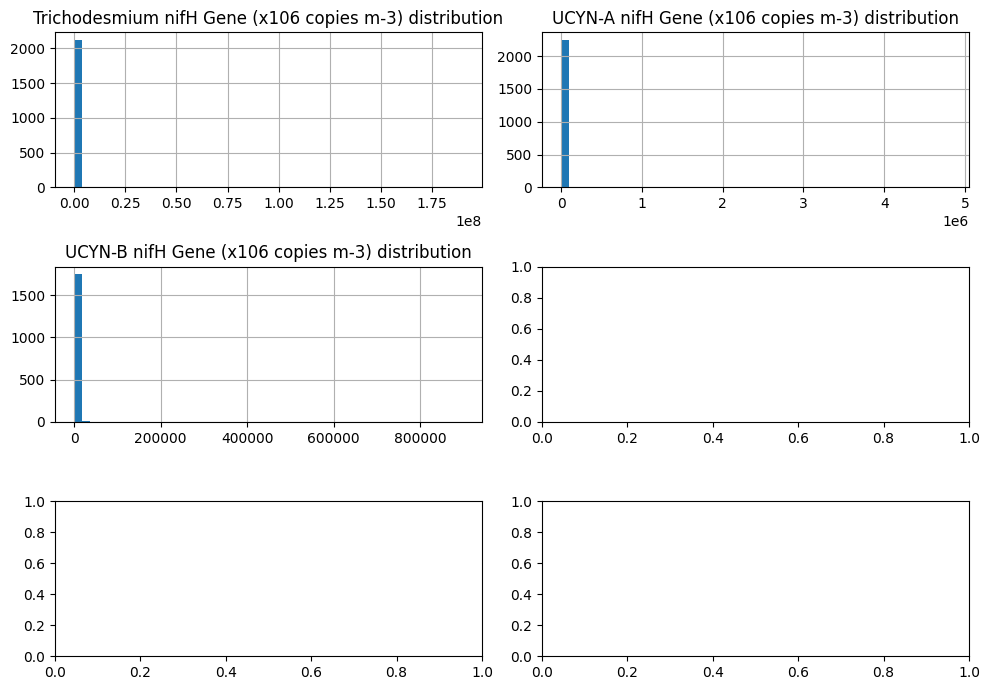

In [136]:
#I want to see the distributions of each variable to see what we are working with 
figure, axis = plt.subplots(3, 2, figsize = (10,7))

#i want to see distributions of the points
axes = axis.flatten()
for i, bact in enumerate(bact_cols):
    title = bact+" distribution"
    ax = axes[i]
    
    combined_df[bact].hist(bins=50,ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

We know from plotting data on a map and the initial plots in the paper, that the authors multiplied it by $10^6$ and plotted on a logarithmic scale. So, I wanted to try multiplication and then taking the logorithm to see the possible results.

0.0
0.0
0.0


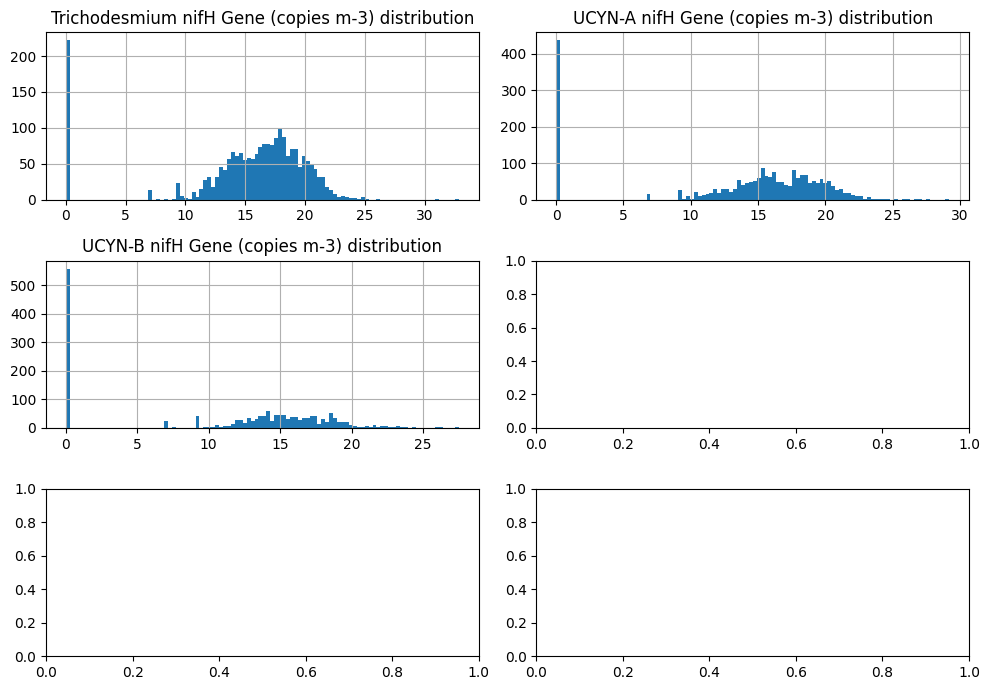

In [137]:
#another plot, but here the data is modified
figure, axis = plt.subplots(3, 2, figsize = (10,7))

#i want to see distributions of the points when we modify it
axes = axis.flatten()
for i, bact in enumerate(bact_cols):
    title = bact+" distribution"
    ax = axes[i]

    mod_ar = np.log(combined_df[bact]*(10**6)+1)
    print(mod_ar.min())
    
    mod_ar.hist(bins=100,ax=ax)
    ax.set_title(title.replace("x106 ",""))

plt.tight_layout()
plt.show()

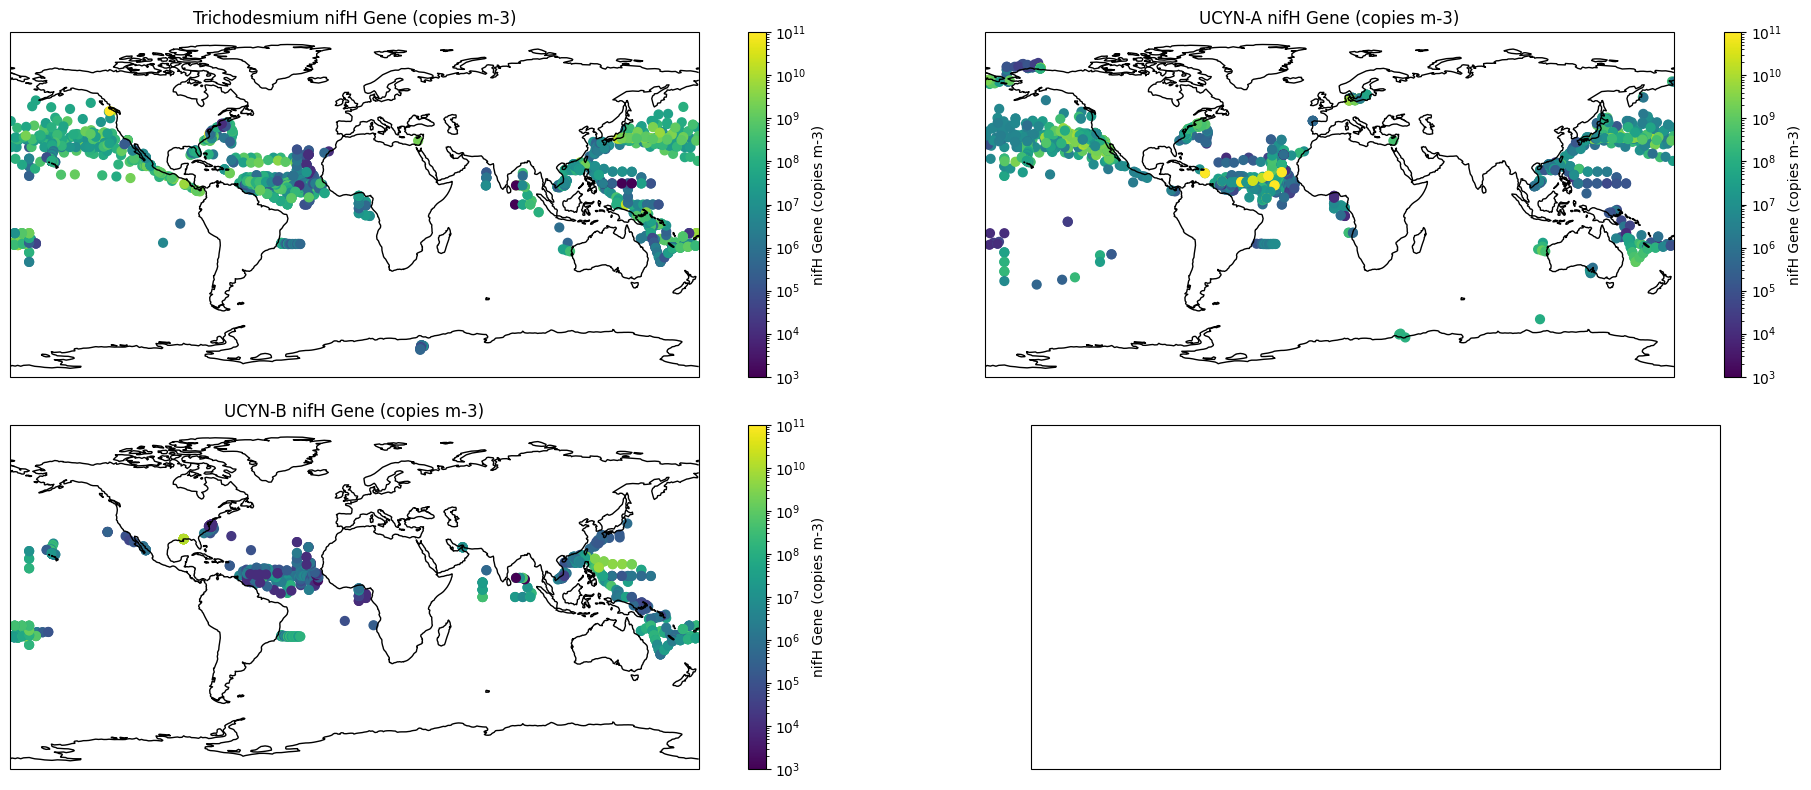

In [138]:
plotColsOnMap(bact_cols, combined_df,True)

### Coordinates grid
Since the coordinate grid is with floating point numbers, this can result in it matching badly with the environmental data, which is only at 0.5 every degree. So, as to avoid having a lot of missing values I tried rounding the coordinates first before averaging.

In [139]:
#we separate the data and coordinates in order to round the coordinate grid
lat_rnd = np.round(combined_df['LATITUDE'])
lon_rnd = np.round(combined_df['LONGITUDE'])
data = combined_df[bact_cols]

#we join the data back together
combined_rnd = pd.concat([data, lat_rnd, lon_rnd], axis=1)
combined_rnd.head()

,Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3),LATITUDE,LONGITUDE
0,0.0,0.03,0.0,-9.0,-137.0
1,0.0,0.00,0.0,-12.0,-134.0
3,0.0,0.00,0.0,-15.0,-130.0
4,0.0,0.00,0.0,-17.0,-128.0
5,0.0,NaN,0.0,-20.0,-123.0


In [140]:
combined_rnd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2857 entries, 0 to 915
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Trichodesmium nifH Gene (x106 copies m-3)  2127 non-null   float64
 1   UCYN-A nifH Gene (x106 copies m-3)         2258 non-null   float64
 2   UCYN-B nifH Gene (x106 copies m-3)         1760 non-null   float64
 3   LATITUDE                                   2857 non-null   float64
 4   LONGITUDE                                  2857 non-null   float64
dtypes: float64(5)
memory usage: 133.9 KB


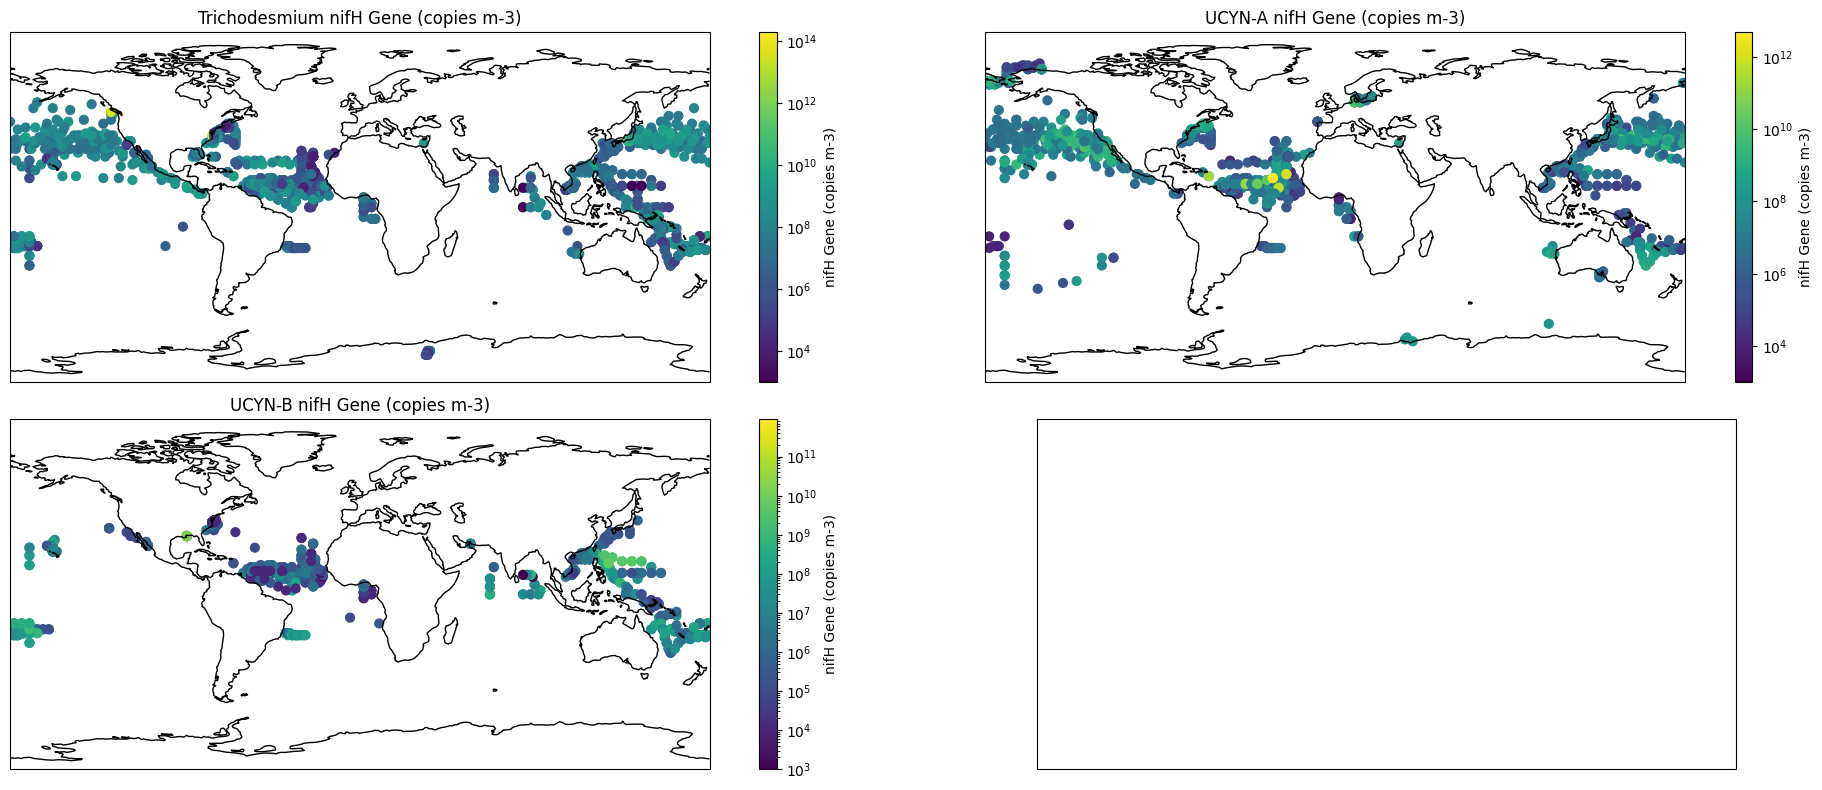

In [141]:
#I wanted to plot the results for comparision
plotColsOnMap(bact_cols,combined_rnd)

In [142]:
#save the data
combined_rnd.to_csv("./csv/features/bact_data.csv")

### Taking the average
Since there likely are several datapoints for each coordinate we should round it first. I am concerned with the null values and how they might affect the data.

In [143]:
#this is to fill the null values, but I am not sure if this is the best strategy
combined_rnd.fillna(0, inplace=True)

In [144]:
#here we group by coordinates and then take the average
combined_avg = combined_rnd.groupby(by=['LATITUDE', 'LONGITUDE']).mean()#first check for nulls and maybe fill them in before averaging
print(combined_avg.columns)
combined_avg.info()

Index(['Trichodesmium nifH Gene (x106 copies m-3)',
       'UCYN-A nifH Gene (x106 copies m-3)',
       'UCYN-B nifH Gene (x106 copies m-3)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1021 entries, (-76.0, 34.0) to (120.0, 25.0)
Data columns (total 3 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Trichodesmium nifH Gene (x106 copies m-3)  1021 non-null   float64
 1   UCYN-A nifH Gene (x106 copies m-3)         1021 non-null   float64
 2   UCYN-B nifH Gene (x106 copies m-3)         1021 non-null   float64
dtypes: float64(3)
memory usage: 30.1 KB


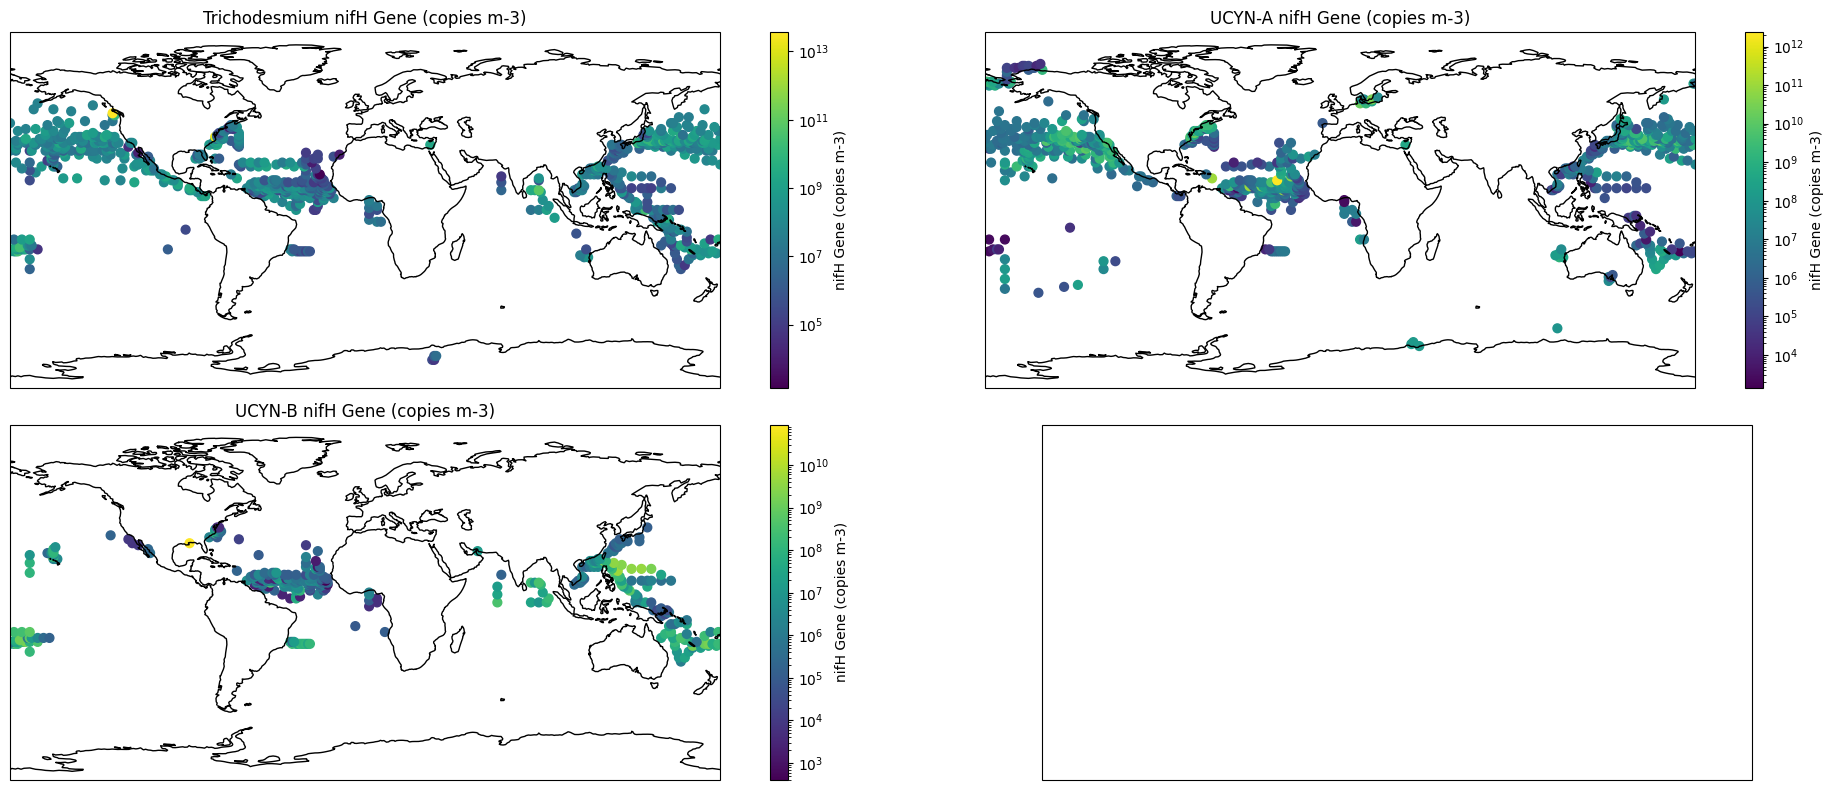

In [145]:
plotColsOnMap(bact_cols,combined_avg)

In [146]:
#save the results
combined_avg.to_csv("./csv/features/bact_data_avg.csv")